<a href="https://colab.research.google.com/github/Maryam-71295/Credit_Risk_Prediction_Internship_Task2/blob/main/Credit_Risk_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Introduction & Problem Statement**

This project aims to predict whether a loan applicant is likely to default on a loan using machine learning techniques. Financial institutions use such models to minimize risk and make informed lending decisions.

The dataset is obtained from Kaggle and includes applicant details such as income, education, loan amount, and credit history.

The goal is to build a classification model that accurately predicts loan approval status.

In [ ]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.gridspec as gridspec
from mpl_toolkits.mplot3d import Axes3D
from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import StandardScaler
from sklearn import preprocessing
from tabulate import tabulate
from sklearn.metrics import roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/creditcard.csv")
df.head().style.set_table_styles(
    [{'selector': 'thead th', 'props': [('background-color', 'skyblue')]}]
)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.000000,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.620000,0
1,0.000000,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.690000,0
2,1.000000,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.660000,0
3,1.000000,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.500000,0
4,2.000000,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.990000,0


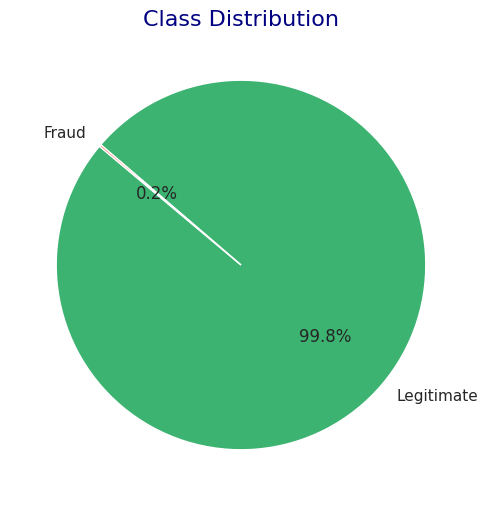

In [ ]:
class_counts = df['Class'].value_counts()
labels = ['Legitimate', 'Fraud']

colors = ['mediumseagreen', 'tomato']

plt.figure(figsize=(6, 6))
plt.pie(class_counts, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title('Class Distribution', color='navy', fontsize=16)
plt.show()

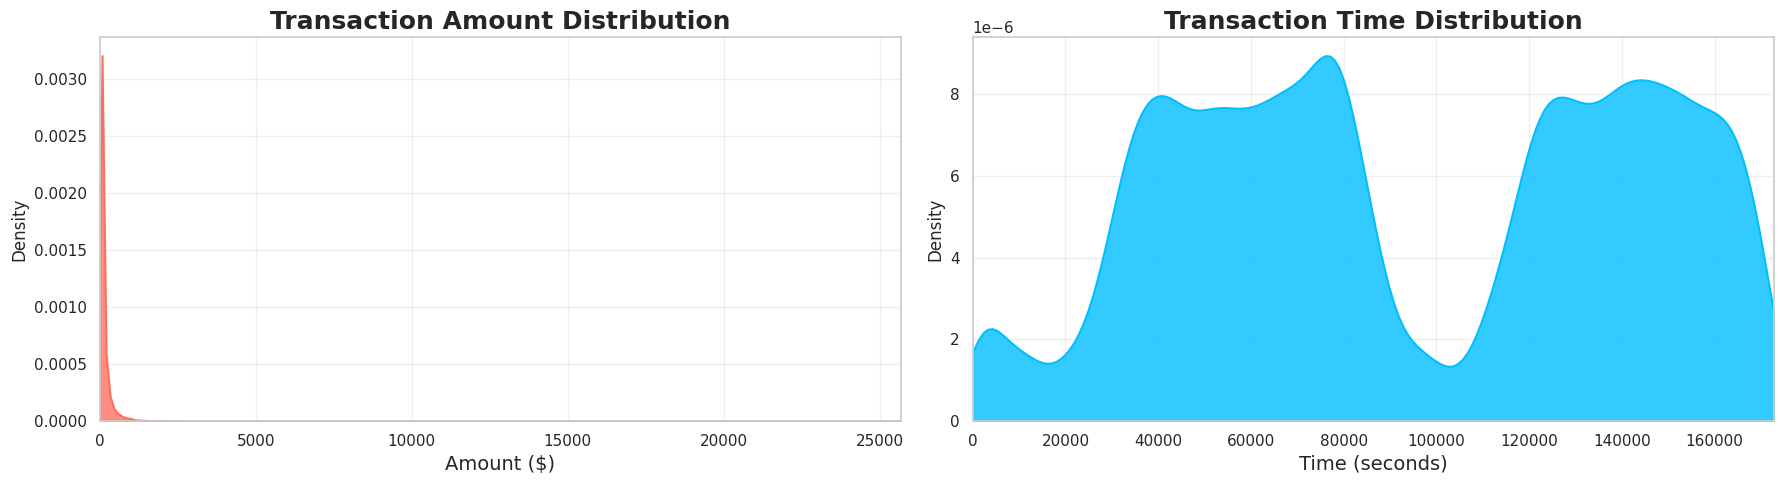

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(18, 5))

Val_Amount = df['Amount'].values
Val_Time = df['Time'].values

# Distribution of Transaction Amount
sns.kdeplot(Val_Amount, ax=ax[0], color="#FF6F61", fill=True, linewidth=1.5, alpha=0.8)
ax[0].set_title('Transaction Amount Distribution', fontsize=18, fontweight='bold')
ax[0].set_xlabel('Amount ($)', fontsize=14)
ax[0].set_xlim([min(Val_Amount), max(Val_Amount)])
ax[0].grid(alpha=0.3)

# Distribution of Transaction Time
sns.kdeplot(Val_Time, ax=ax[1], color="#00BFFF", fill=True, linewidth=1.5, alpha=0.8)
ax[1].set_title('Transaction Time Distribution', fontsize=18, fontweight='bold')
ax[1].set_xlabel('Time (seconds)', fontsize=14)
ax[1].set_xlim([min(Val_Time), max(Val_Time)])
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

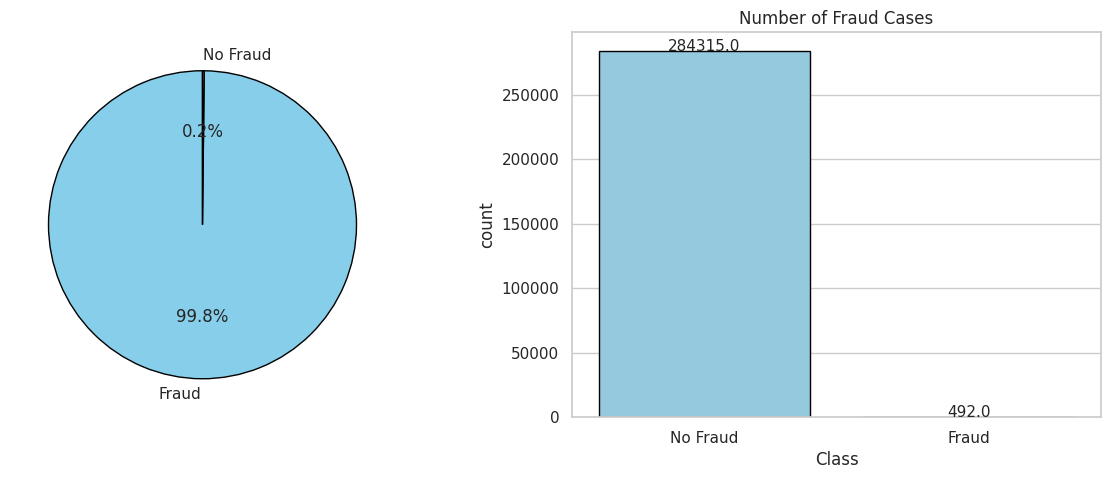

In [ ]:
%matplotlib inline
pd.options.display.float_format = '{:.2f}'.format
fraud = len(df[df['Class'] == 1]) / len(df) * 100
nofraud = len(df[df['Class'] == 0]) / len(df) * 100
fraud_percentage = [nofraud,fraud]

colors = ["skyblue", "salmon"]

fig,ax = plt.subplots(nrows = 1,ncols = 2,figsize = (15,5))
plt.subplot(1,2,1)
plt.pie(fraud_percentage,labels = ['Fraud','No Fraud'],autopct='%1.1f%%',startangle = 90,colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})

plt.subplot(1,2,2)
sns.countplot(x='Class',data = df,edgecolor = 'black',palette = colors)

for rect in ax[1].patches:
    ax[1].text(rect.get_x() + rect.get_width() / 2, rect.get_height() + 2, rect.get_height(), horizontalalignment='center', fontsize = 11)
ax[1].set_xticklabels(['No Fraud','Fraud'])
plt.title('Number of Fraud Cases');

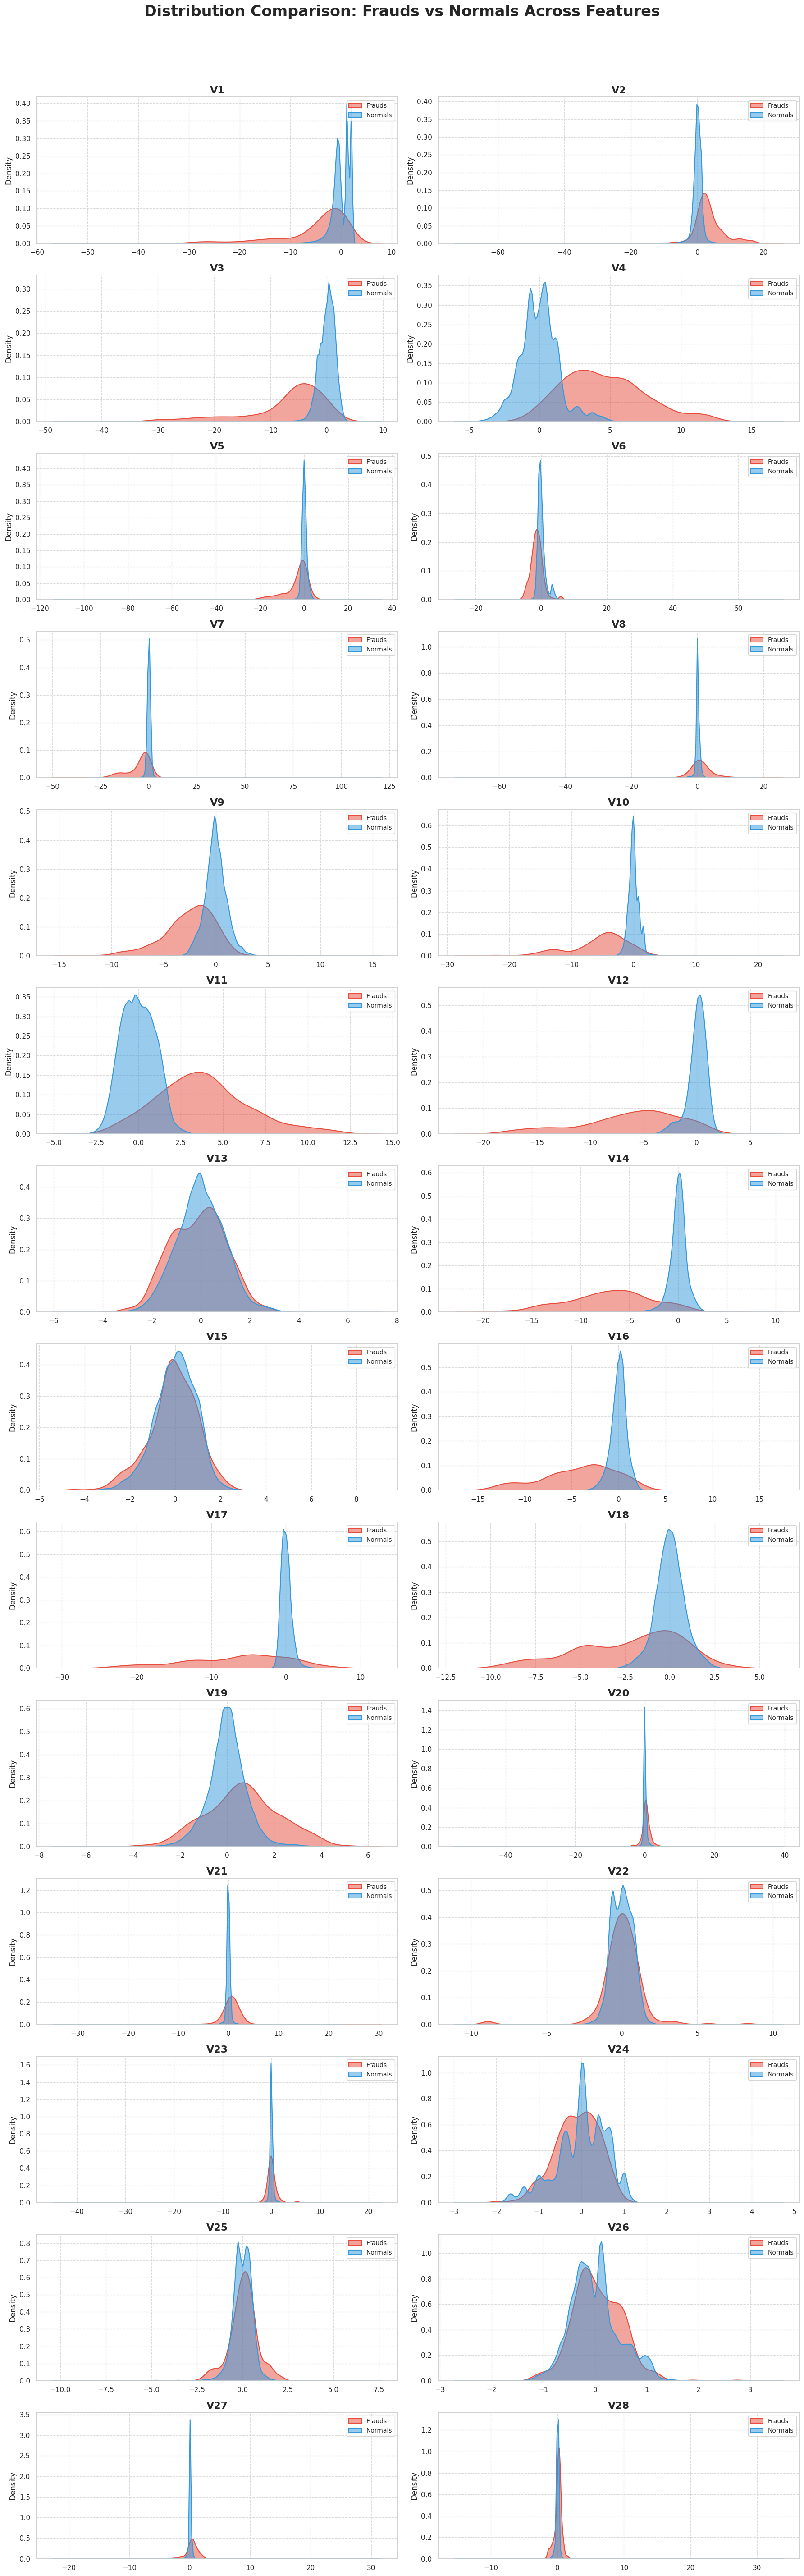

In [ ]:
columns = df.iloc[:, 1:29].columns

frauds = df['Class'] == 1
normals = df['Class'] == 0

sns.set_style("whitegrid")

grid = gridspec.GridSpec(14, 2)
fig = plt.figure(figsize=(18, 56))

fraud_color = "#e74c3c"   # Crimson Red
normal_color = "#3498db"  # Soft Blue

for n, col in enumerate(columns):
    ax = plt.subplot(grid[n])

    sns.kdeplot(
        data=df.loc[frauds], x=col,
        fill=True, color=fraud_color, alpha=0.5,
        linewidth=1.5, label="Frauds", ax=ax
    )
    sns.kdeplot(
        data=df.loc[normals], x=col,
        fill=True, color=normal_color, alpha=0.5,
        linewidth=1.5, label="Normals", ax=ax
    )

    ax.set_ylabel('Density', fontsize=12)
    ax.set_title(col, fontsize=16, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(fontsize=10, loc="upper right")
    ax.grid(True, linestyle='--', alpha=0.7)

fig.suptitle('Distribution Comparison: Frauds vs Normals Across Features', fontsize=24, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
print(df.shape)

(284807, 31)


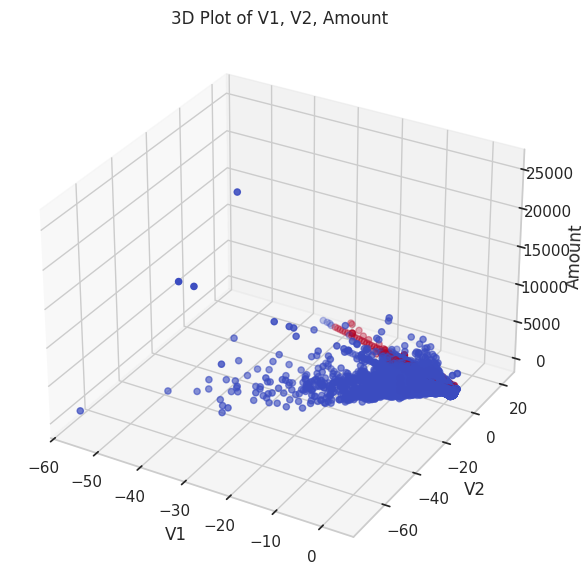

In [ ]:
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df['V1'], df['V2'], df['Amount'], c=df['Class'], cmap='coolwarm')
ax.set_xlabel('V1')
ax.set_ylabel('V2')
ax.set_zlabel('Amount')
plt.title('3D Plot of V1, V2, Amount')
plt.show()

In [ ]:
print(df[df['Class']==1]['Amount'].describe())

count    492.00
mean     122.21
std      256.68
min        0.00
25%        1.00
50%        9.25
75%      105.89
max     2125.87
Name: Amount, dtype: float64


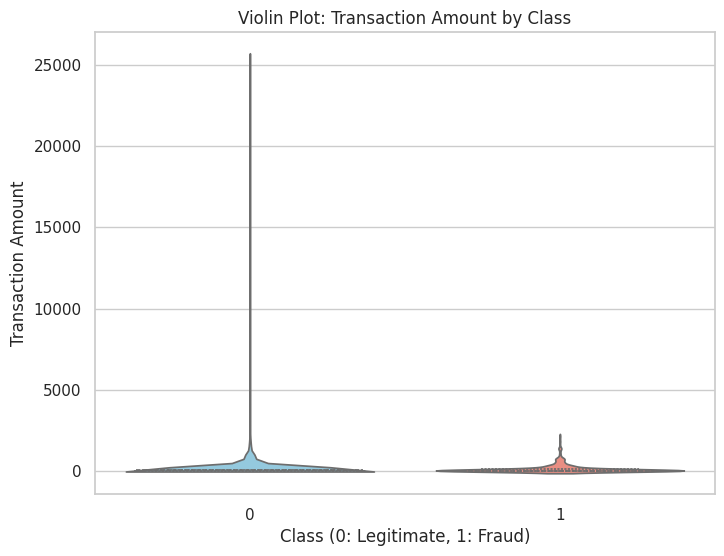

In [ ]:
plt.figure(figsize=(8, 6))
sns.violinplot(data=df, x='Class', y='Amount', palette=['skyblue', 'salmon'], inner='quartile')
plt.title('Violin Plot: Transaction Amount by Class')
plt.xlabel('Class (0: Legitimate, 1: Fraud)')
plt.ylabel('Transaction Amount')
plt.show()

In [ ]:
print("\nUnique values in each column:")
print(df.nunique())

print("\nData Types of each column:")
print(df.dtypes)


Unique values in each column:
Time      124592
V1        275663
V2        275663
V3        275663
V4        275663
V5        275663
V6        275663
V7        275663
V8        275663
V9        275663
V10       275663
V11       275663
V12       275663
V13       275663
V14       275663
V15       275663
V16       275663
V17       275663
V18       275663
V19       275663
V20       275663
V21       275663
V22       275663
V23       275663
V24       275663
V25       275663
V26       275663
V27       275663
V28       275663
Amount     32767
Class          2
dtype: int64

Data Types of each column:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22  

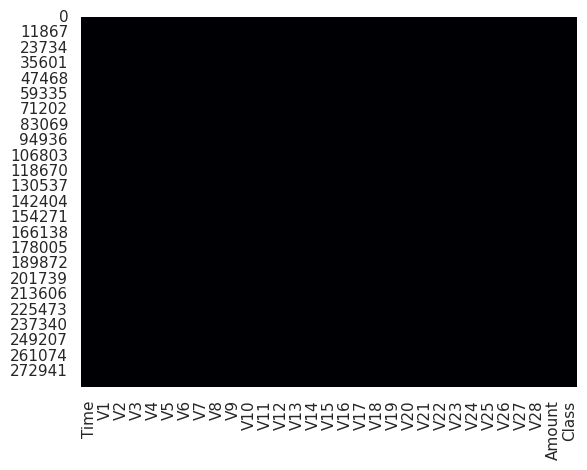

In [ ]:
sns.heatmap(df.isnull(),cmap = 'magma',cbar = False);

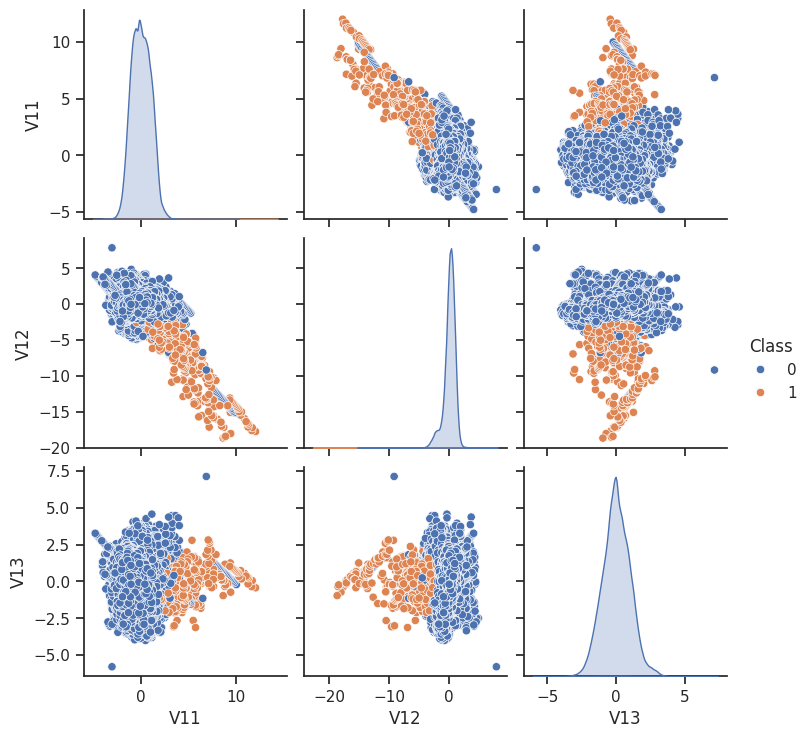

In [ ]:
sns.set(style="ticks")
sns.pairplot(df[["V11","V12","V13","Class"]], hue="Class")

Total duplicate rows: 1081


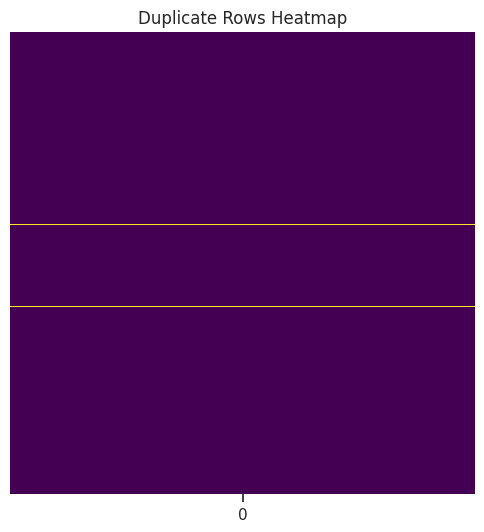

In [ ]:
def visualize_duplicates(df):
    duplicate_count = df.duplicated().sum()
    print(f"Total duplicate rows: {duplicate_count}")

    plt.figure(figsize=(6, 6))
    sns.heatmap(df.duplicated(keep=False).to_frame(), cbar=False, cmap="viridis", yticklabels=False)
    plt.title("Duplicate Rows Heatmap")
    plt.show()

visualize_duplicates(df)

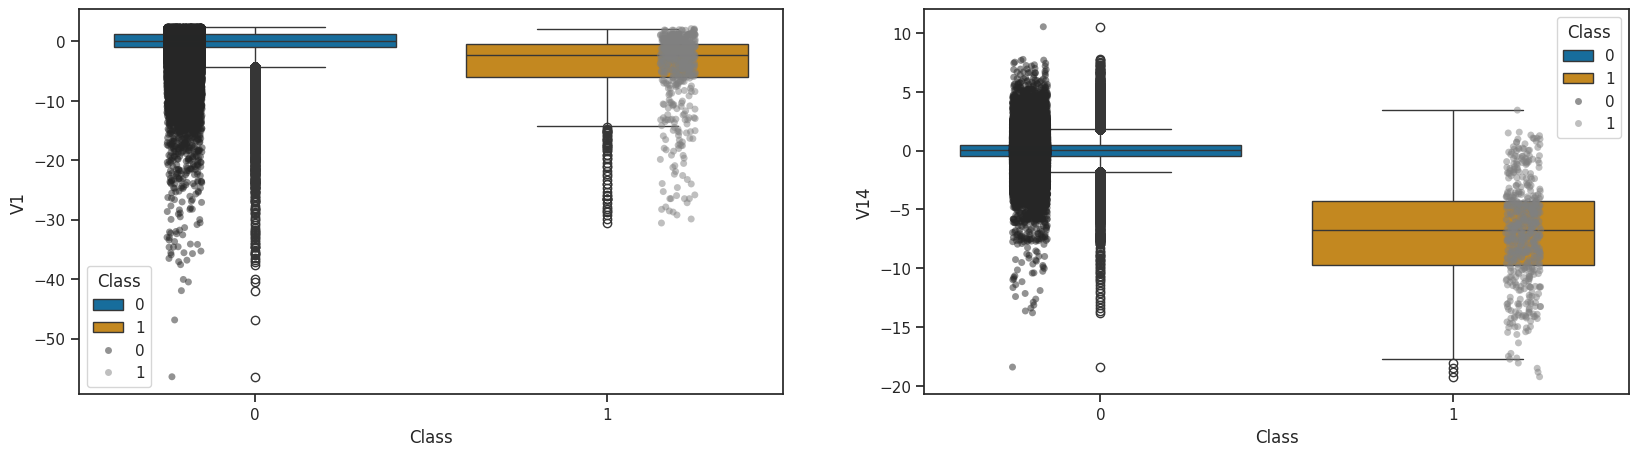

In [ ]:
cols = ['V1', 'V14']
f, axes = plt.subplots(1, 2, figsize=(20, 5), sharex=True)
for index,col in enumerate(cols):
    sns.boxplot(x="Class", y=col, hue="Class", palette="colorblind", data=df, ax=axes[index])
    sns.stripplot(x='Class', y=col,  data=df,dodge=True,jitter=True,marker='o',ax=axes[index],alpha=0.5,color='grey',hue='Class')
plt.show()
plt.clf()
plt.close()

In [ ]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

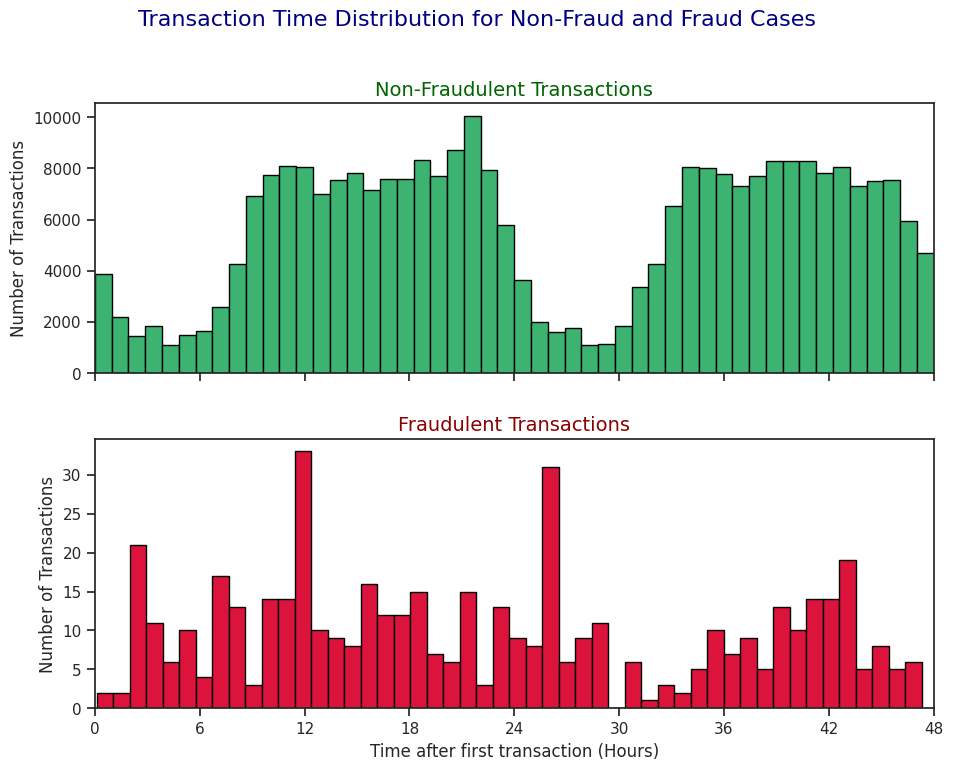

In [ ]:
# Relation of Non-Frauds and Frauds with Transaction Time
transaction_time_hours = df["Time"] / 3600  # Convert seconds to hours

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 8))

# Non-Fraud transactions
ax1.hist(transaction_time_hours[df["Class"] == 0], bins=50, color="mediumseagreen", edgecolor='black')
ax1.set_title("Non-Fraudulent Transactions", fontsize=14, color='darkgreen')
ax1.set_ylabel('Number of Transactions')

# Fraud transactions
ax2.hist(transaction_time_hours[df["Class"] == 1], bins=50, color="crimson", edgecolor='black')
ax2.set_title("Fraudulent Transactions", fontsize=14, color='darkred')
ax2.set_xlabel("Time after first transaction (Hours)")
ax2.set_ylabel('Number of Transactions')

plt.xticks(np.arange(0, 54, 6))
plt.xlim([0, 48])
plt.suptitle('Transaction Time Distribution for Non-Fraud and Fraud Cases', fontsize=16, color='navy')
plt.tight_layout(pad=2)
plt.show()

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.00,94813.86,47488.15,0.00,54201.50,84692.00,139320.50,172792.00
V1,284807.00,0.00,1.96,-56.41,-0.92,0.02,1.32,2.45
V2,284807.00,0.00,1.65,-72.72,-0.60,0.07,0.80,22.06
V3,284807.00,-0.00,1.52,-48.33,-0.89,0.18,1.03,9.38
V4,284807.00,0.00,1.42,-5.68,-0.85,-0.02,0.74,16.88
V5,284807.00,0.00,1.38,-113.74,-0.69,-0.05,0.61,34.80
V6,284807.00,0.00,1.33,-26.16,-0.77,-0.27,0.40,73.30
V7,284807.00,-0.00,1.24,-43.56,-0.55,0.04,0.57,120.59
V8,284807.00,0.00,1.19,-73.22,-0.21,0.02,0.33,20.01
V9,284807.00,-0.00,1.10,-13.43,-0.64,-0.05,0.60,15.59


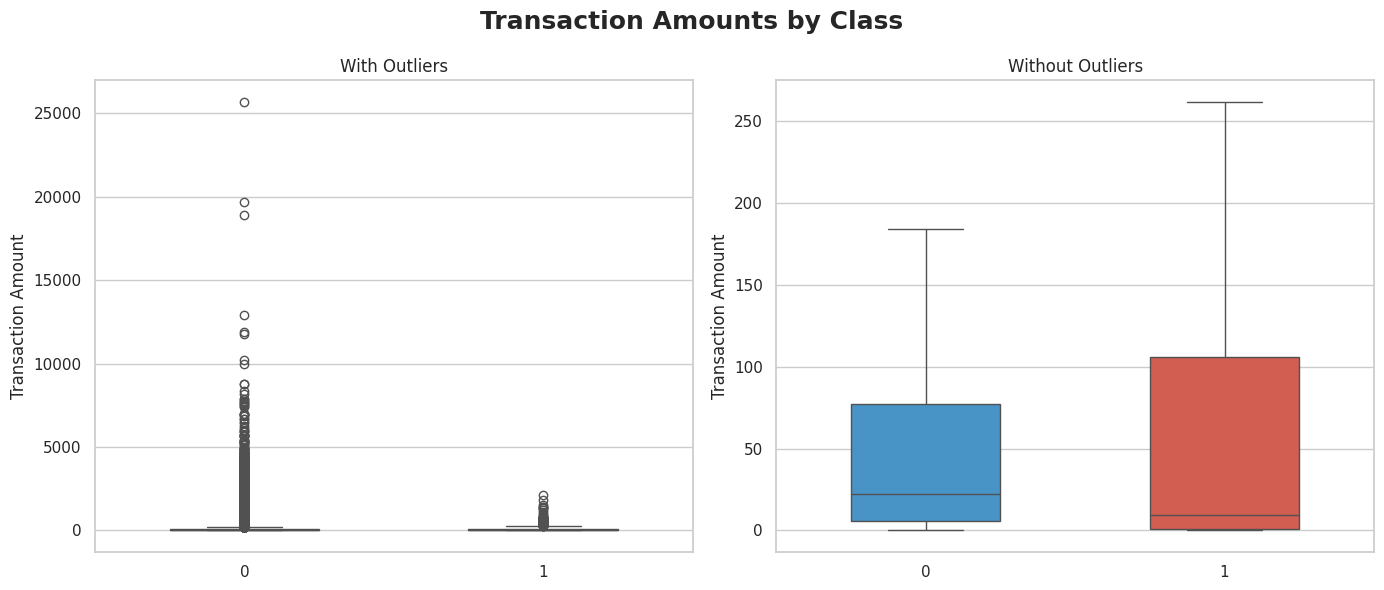

In [ ]:
sns.set_style("whitegrid")
palette = {0: "#3498db", 1: "#e74c3c"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(ax=ax1, x="Class", y="Amount", data=df, hue="Class", palette=palette, showfliers=True, width=0.5)
ax1.set_title('With Outliers')

sns.boxplot(ax=ax2, x="Class", y="Amount", data=df, hue="Class", palette=palette, showfliers=False, width=0.5)
ax2.set_title('Without Outliers')

for ax in (ax1, ax2):
    ax.set_xlabel(''); ax.set_ylabel('Transaction Amount')
    ax.legend_.remove()

plt.suptitle('Transaction Amounts by Class', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
timedelta = pd.to_timedelta(df['Time'], unit='s')

df['mins'] = (timedelta.dt.components.minutes).astype(int)
df['hours'] = (timedelta.dt.components.hours).astype(int)

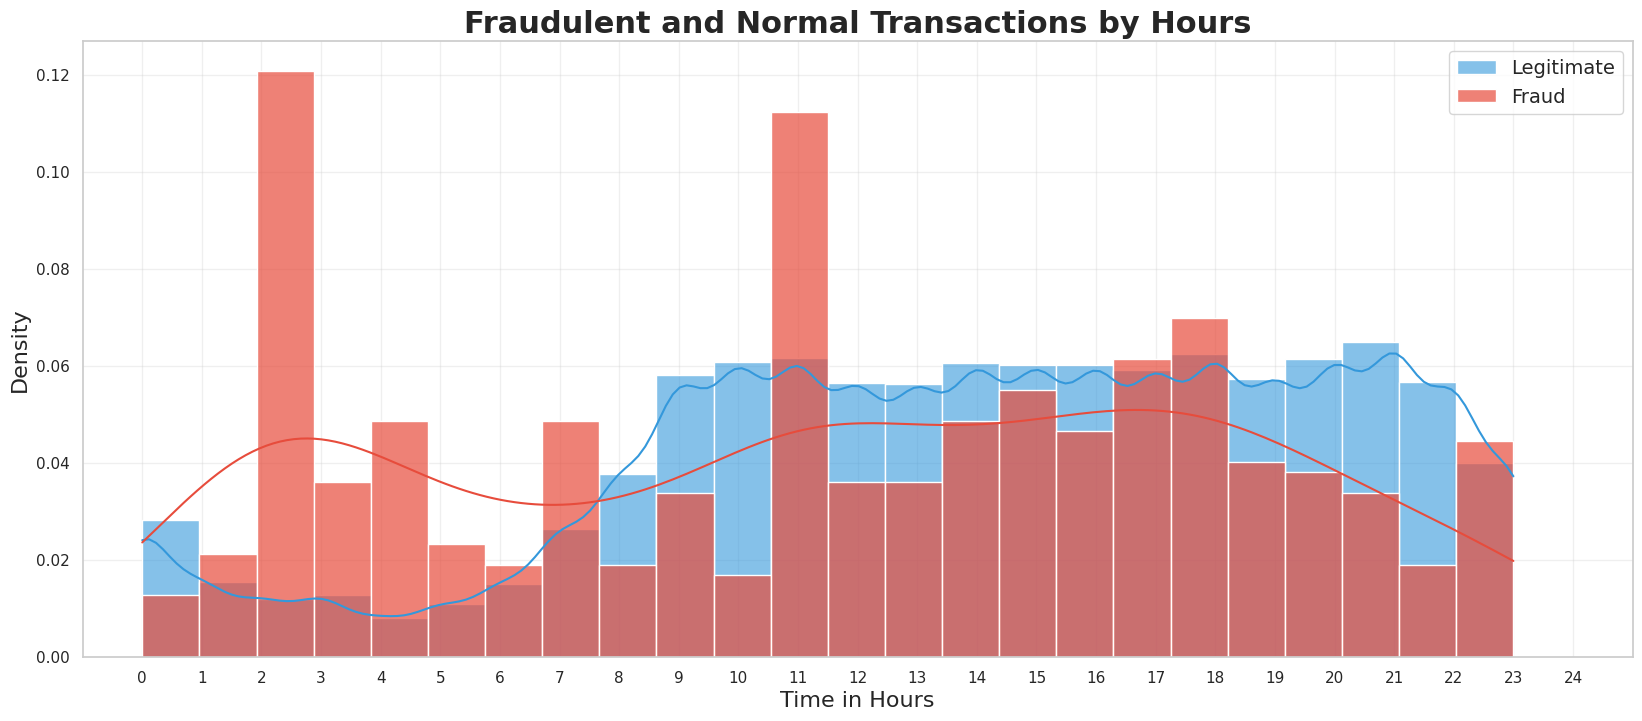

In [ ]:
plt.figure(figsize=(20, 8))

sns.histplot(df[df['Class'] == 0]['hours'], bins=24, color='#3498db', label='Legitimate', kde=True, stat="density", alpha=0.6)
sns.histplot(df[df['Class'] == 1]['hours'], bins=24, color='#e74c3c', label='Fraud', kde=True, stat="density", alpha=0.7)

plt.title('Fraudulent and Normal Transactions by Hours', fontsize=22, fontweight='bold')
plt.xlabel('Time in Hours', fontsize=16)
plt.ylabel('Density', fontsize=16)
plt.xticks(range(0, 25))
plt.xlim([-1, 25])
plt.legend(fontsize=14)
plt.grid(alpha=0.3)
plt.show()

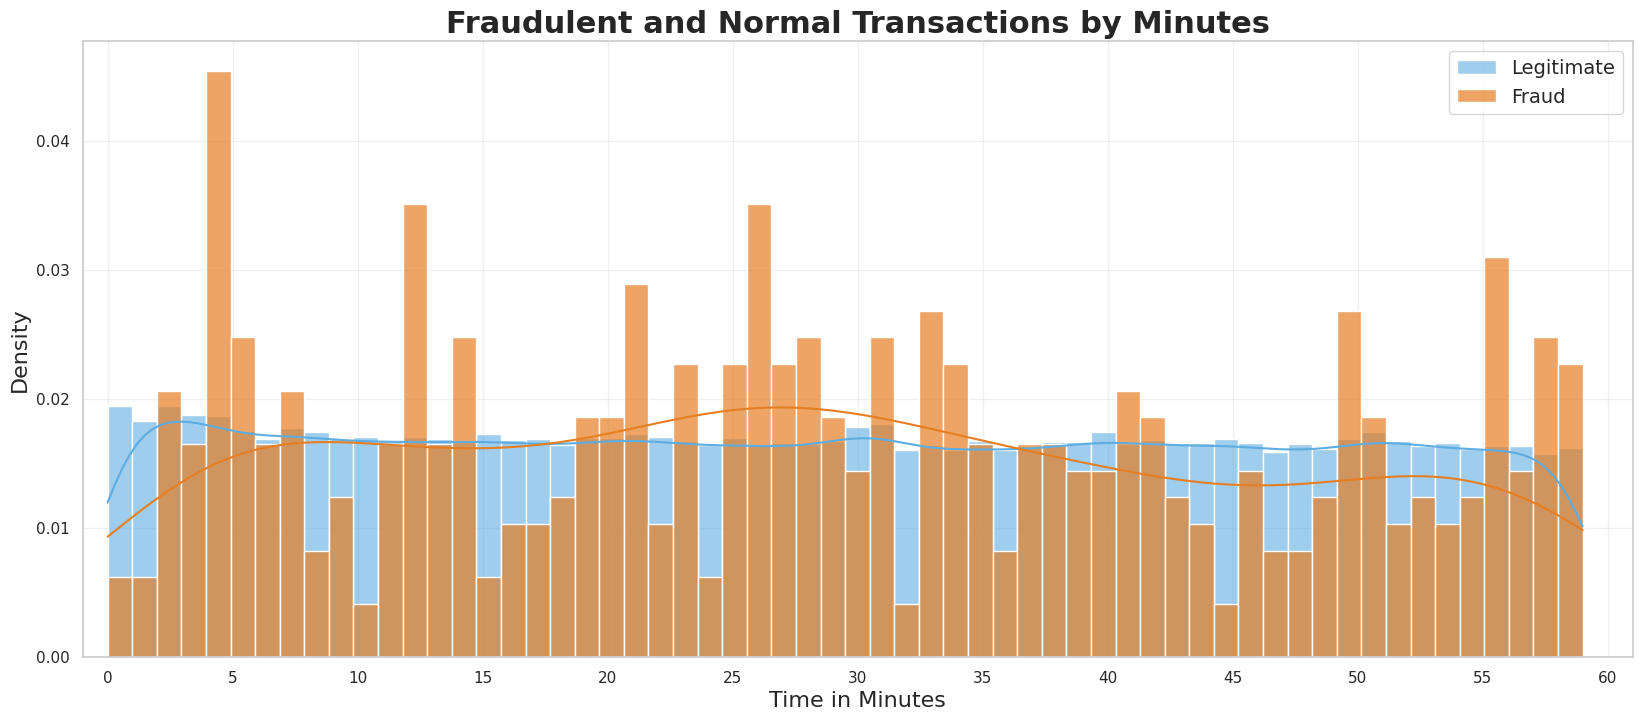

In [ ]:
plt.figure(figsize=(20, 8))

sns.histplot(df[df['Class'] == 0]['mins'], bins=60, color='#5DADE2', label='Legitimate', kde=True, stat="density", alpha=0.6)
sns.histplot(df[df['Class'] == 1]['mins'], bins=60, color='#E67E22', label='Fraud', kde=True, stat="density", alpha=0.7)

plt.title('Fraudulent and Normal Transactions by Minutes', fontsize=22, fontweight='bold')
plt.xlabel('Time in Minutes', fontsize=16)
plt.ylabel('Density', fontsize=16)
plt.xticks(range(0, 61, 5))
plt.xlim([-1, 61])
plt.legend(fontsize=14)
plt.grid(alpha=0.3)
plt.show()

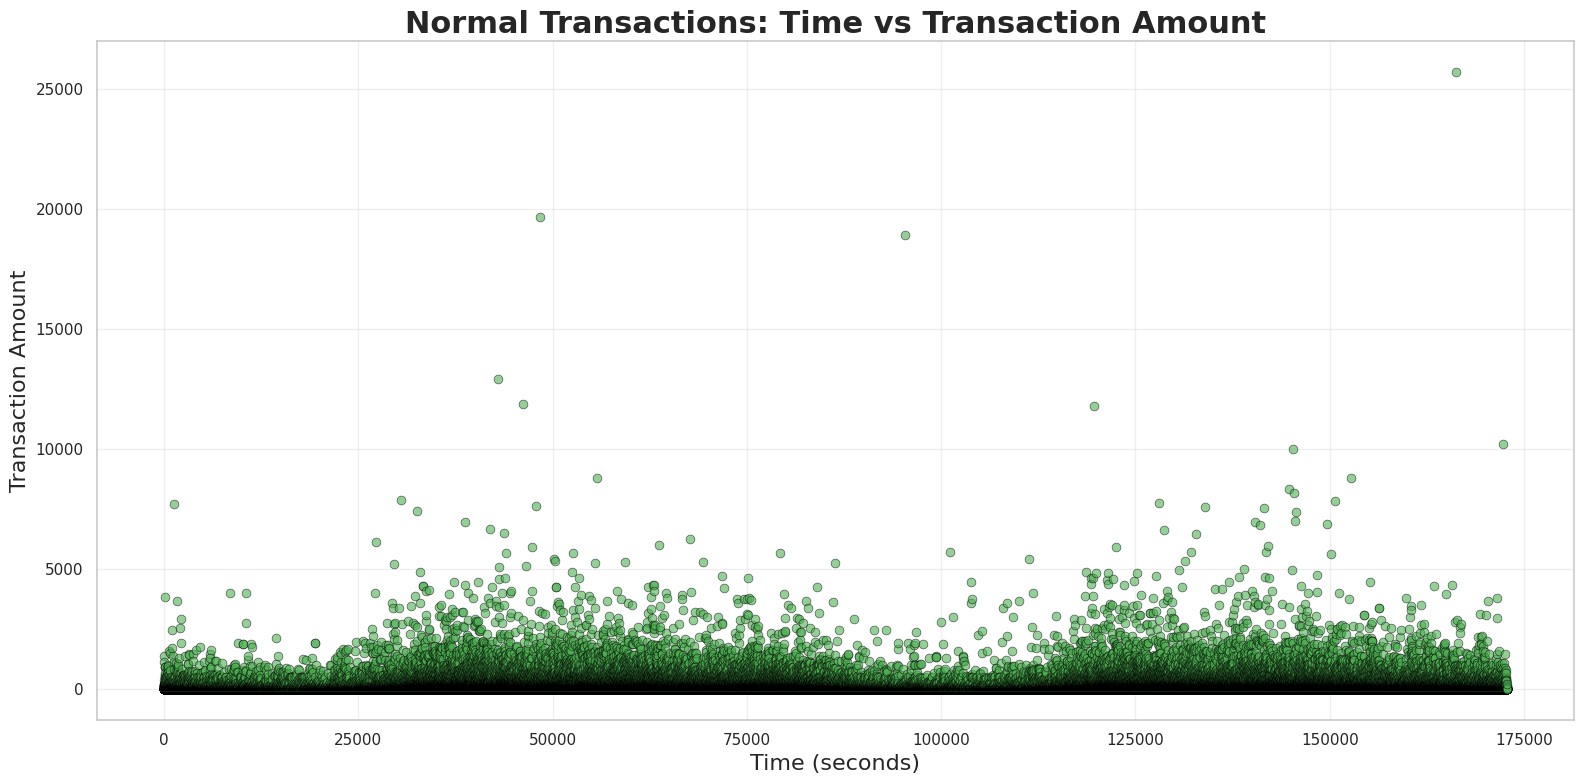

In [ ]:
plt.figure(figsize=(16, 8))

plt.scatter(
    x=df[df['Class'] == 0]['Time'],
    y=df[df['Class'] == 0]['Amount'],
    color="#4CAF50",
    edgecolor='black',
    s=40,
    alpha=0.6,
    linewidth=0.5
)

plt.title("Normal Transactions: Time vs Transaction Amount", fontsize=22, fontweight='bold')
plt.xlabel("Time (seconds)", fontsize=16)
plt.ylabel("Transaction Amount", fontsize=16)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

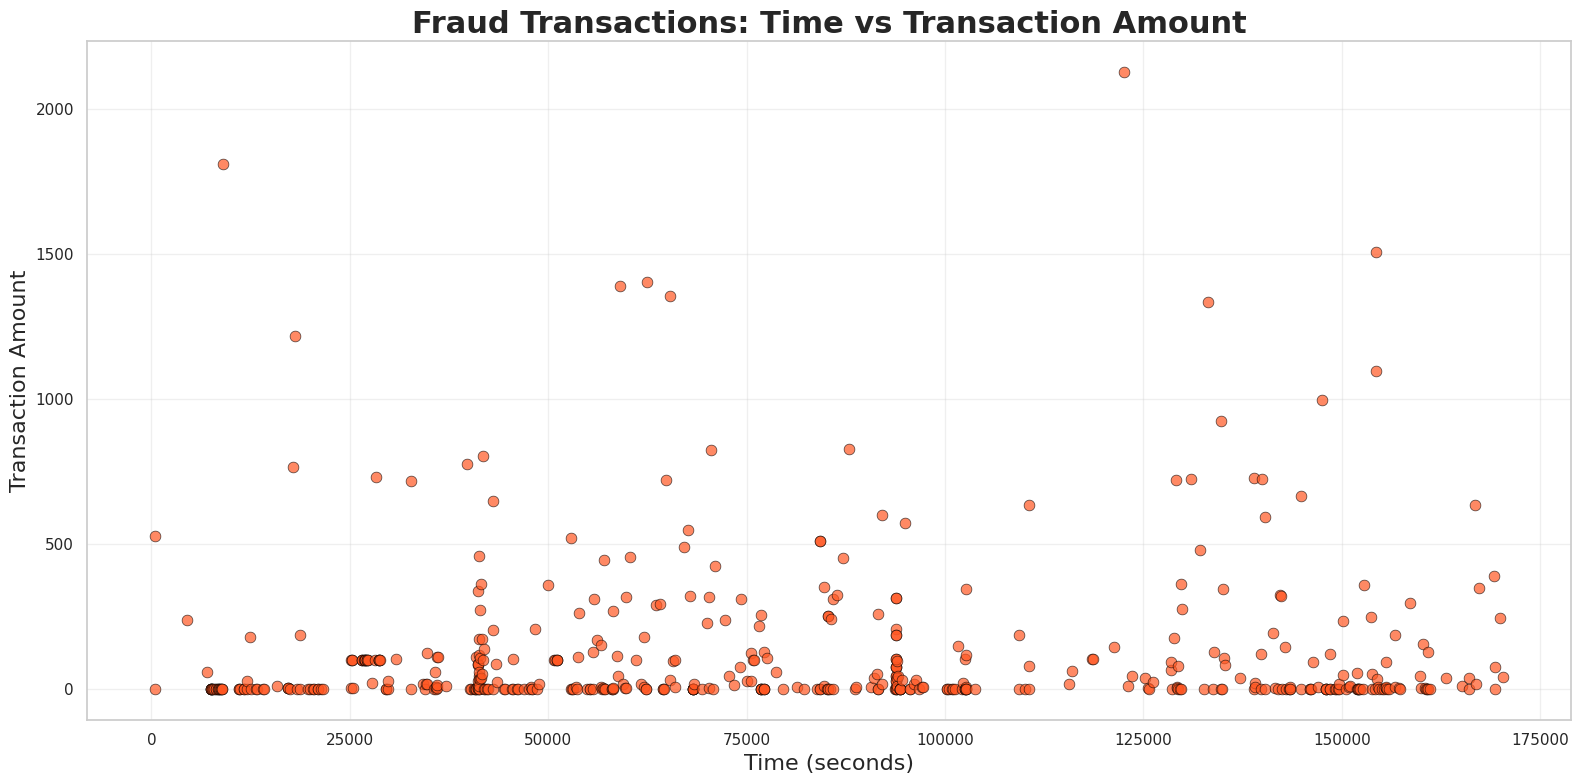

In [ ]:
plt.figure(figsize=(16, 8))

plt.scatter(
    x=df[df['Class'] == 1]['Time'],
    y=df[df['Class'] == 1]['Amount'],
    color="#FF5722",
    edgecolor='black',
    s=60,
    alpha=0.7,
    linewidth=0.5
)

plt.title("Fraud Transactions: Time vs Transaction Amount", fontsize=22, fontweight='bold')
plt.xlabel("Time (seconds)", fontsize=16)
plt.ylabel("Transaction Amount", fontsize=16)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
df = df.dropna()
df = df.drop_duplicates()

<Axes: xlabel='Class', ylabel='count'>

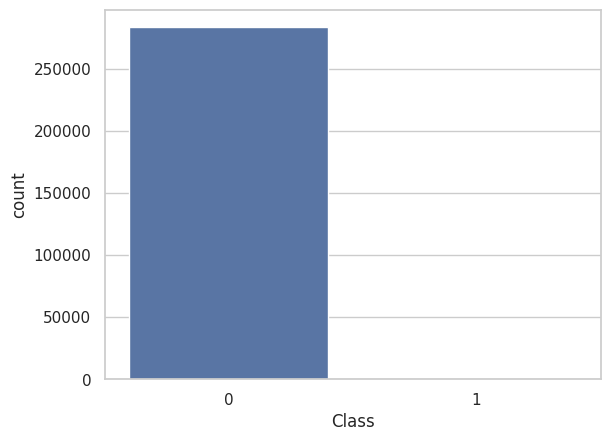

In [ ]:
# Visualizing the Class distribution
sns.countplot(x="Class", data=df)

In [ ]:
# Under-sampling
undersample = RandomUnderSampler(sampling_strategy= 0.5)
cols = df.columns.tolist()
cols = [c for c in cols if c not in ["Class"]]
target = "Class"
X = df[cols]
Y = df[target]
X_under, Y_under = undersample.fit_resample(X, Y)
test = pd.DataFrame(Y_under, columns=['Class'])

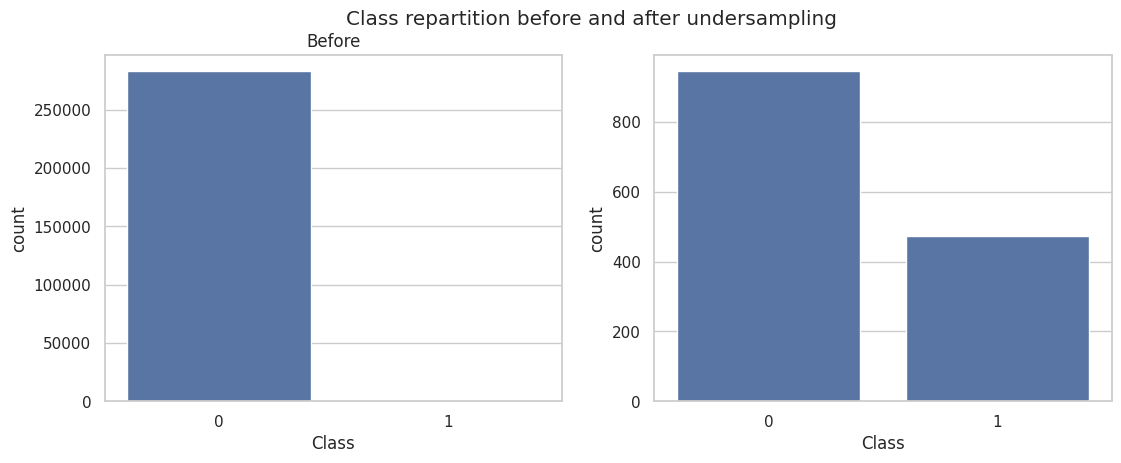

In [ ]:
# Visualizing undersampling results
fig, axs = plt.subplots(ncols=2, figsize=(13, 4.5))
sns.countplot(x="Class", data=df, ax=axs[0])
sns.countplot(x="Class", data=test, ax=axs[1])
fig.suptitle("Class repartition before and after undersampling")
a1 = fig.axes[0]
a1.set_title("Before")
a2 = fig.axes[1]

<Axes: >

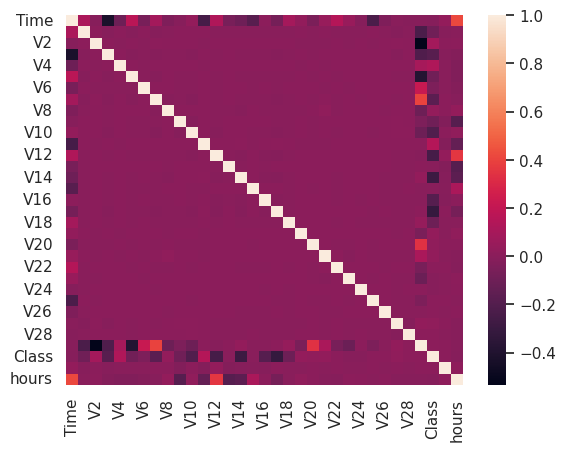

In [ ]:
sns.heatmap(df.corr())

In [ ]:
# StandardScaler
scaler = preprocessing.StandardScaler()
df['std_Amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df = df.drop("Amount", axis=1)

In [ ]:
df = df.drop("Time", axis=1)

In [ ]:
X=df.drop(['Class'],axis=1)
X.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,mins,hours,std_Amount
0,-1.36,-0.07,2.54,1.38,-0.34,0.46,0.24,0.10,0.36,0.09,...,0.28,-0.11,0.07,0.13,-0.19,0.13,-0.02,0,0,0.24
1,1.19,0.27,0.17,0.45,0.06,-0.08,-0.08,0.09,-0.26,-0.17,...,-0.64,0.10,-0.34,0.17,0.13,-0.01,0.01,0,0,-0.34
2,-1.36,-1.34,1.77,0.38,-0.50,1.80,0.79,0.25,-1.51,0.21,...,0.77,0.91,-0.69,-0.33,-0.14,-0.06,-0.06,0,0,1.16
3,-0.97,-0.19,1.79,-0.86,-0.01,1.25,0.24,0.38,-1.39,-0.05,...,0.01,-0.19,-1.18,0.65,-0.22,0.06,0.06,0,0,0.14
4,-1.16,0.88,1.55,0.40,-0.41,0.10,0.59,-0.27,0.82,0.75,...,0.80,-0.14,0.14,-0.21,0.50,0.22,0.22,0,0,-0.07


In [ ]:
Y=df['Class']
Y.head()

,Class
0,0
1,0
2,0
3,0
4,0


In [ ]:
df.describe()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V23,V24,V25,V26,V27,V28,Class,mins,hours,std_Amount
count,283726.00,283726.00,283726.00,283726.00,283726.00,283726.00,283726.00,283726.00,283726.00,283726.00,...,283726.00,283726.00,283726.00,283726.00,283726.00,283726.00,283726.00,283726.00,283726.00,283726.00
mean,0.01,-0.00,0.00,-0.00,0.00,-0.00,0.00,-0.00,-0.00,-0.00,...,0.00,0.00,-0.00,0.00,0.00,0.00,0.00,29.00,14.05,-0.00
std,1.95,1.65,1.51,1.41,1.38,1.33,1.23,1.18,1.10,1.08,...,0.62,0.61,0.52,0.48,0.40,0.33,0.04,17.43,5.83,1.00
min,-56.41,-72.72,-48.33,-5.68,-113.74,-26.16,-43.56,-73.22,-13.43,-24.59,...,-44.81,-2.84,-10.30,-2.60,-22.57,-15.43,0.00,0.00,0.00,-0.35
25%,-0.92,-0.60,-0.89,-0.85,-0.69,-0.77,-0.55,-0.21,-0.64,-0.54,...,-0.16,-0.35,-0.32,-0.33,-0.07,-0.05,0.00,14.00,10.00,-0.33
50%,0.02,0.06,0.18,-0.02,-0.05,-0.28,0.04,0.02,-0.05,-0.09,...,-0.01,0.04,0.02,-0.05,0.00,0.01,0.00,29.00,15.00,-0.27
75%,1.32,0.80,1.03,0.74,0.61,0.40,0.57,0.33,0.60,0.45,...,0.15,0.44,0.35,0.24,0.09,0.08,0.00,44.00,19.00,-0.04
max,2.45,22.06,9.38,16.88,34.80,73.30,120.59,20.01,15.59,23.75,...,22.53,4.58,7.52,3.52,31.61,33.85,1.00,59.00,23.00,102.25


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X_under, Y_under, test_size=0.2, random_state=42)

Accuracy for Support Vector Machine: 0.6338
Classification Report for Support Vector Machine:

              precision    recall  f1-score   support

           0       0.63      1.00      0.78       180
           1       0.00      0.00      0.00       104

    accuracy                           0.63       284
   macro avg       0.32      0.50      0.39       284
weighted avg       0.40      0.63      0.49       284

------------------------------------------------------------


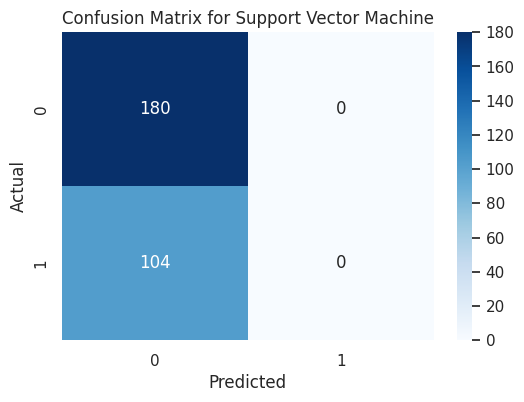

Accuracy for Random Forest: 0.9472
Classification Report for Random Forest:

              precision    recall  f1-score   support

           0       0.93      0.99      0.96       180
           1       0.99      0.87      0.92       104

    accuracy                           0.95       284
   macro avg       0.96      0.93      0.94       284
weighted avg       0.95      0.95      0.95       284

------------------------------------------------------------


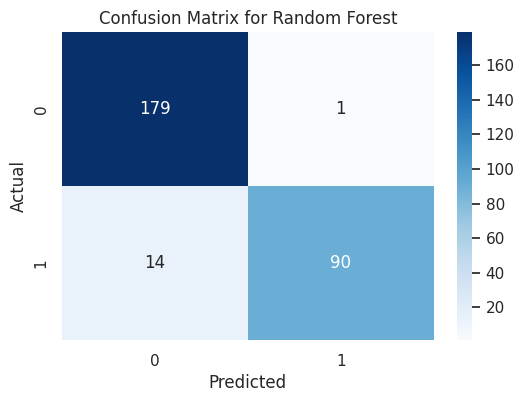

Accuracy for XGBoost: 0.9577
Classification Report for XGBoost:

              precision    recall  f1-score   support

           0       0.94      0.99      0.97       180
           1       0.99      0.89      0.94       104

    accuracy                           0.96       284
   macro avg       0.97      0.94      0.95       284
weighted avg       0.96      0.96      0.96       284

------------------------------------------------------------


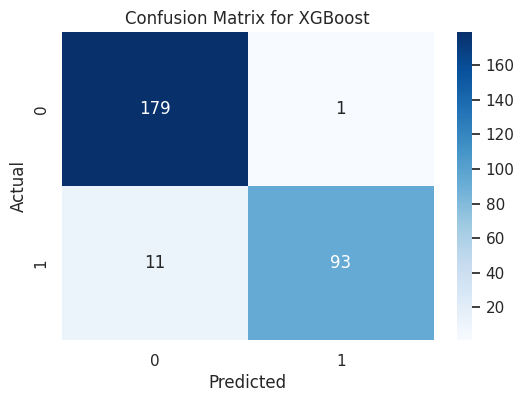

Accuracy for Logistic Regression: 0.9437
Classification Report for Logistic Regression:

              precision    recall  f1-score   support

           0       0.92      0.99      0.96       180
           1       0.99      0.86      0.92       104

    accuracy                           0.94       284
   macro avg       0.96      0.93      0.94       284
weighted avg       0.95      0.94      0.94       284

------------------------------------------------------------


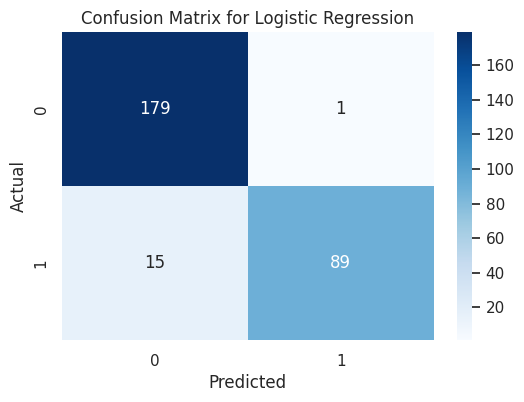

Accuracy for Decision Tree: 0.9155
Classification Report for Decision Tree:

              precision    recall  f1-score   support

           0       0.92      0.95      0.93       180
           1       0.91      0.86      0.88       104

    accuracy                           0.92       284
   macro avg       0.91      0.90      0.91       284
weighted avg       0.92      0.92      0.91       284

------------------------------------------------------------


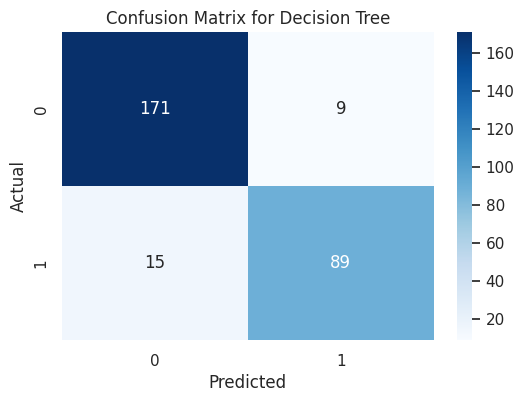

In [ ]:
models = {

    'Support Vector Machine': SVC(probability=True),
    'Random Forest': RandomForestClassifier(),
    'XGBoost': XGBClassifier(),
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier()
}

results = []

for name, model in models.items():
    model.fit(X_train, Y_train)

    y_pred = model.predict(X_test)
    accuracy = accuracy_score(Y_test, y_pred)
    results.append({'Model': name, 'Accuracy': accuracy})


    print(f'Accuracy for {name}: {accuracy:.4f}')
    print(f'Classification Report for {name}:\n')
    print(classification_report(Y_test, y_pred))
    print('-' * 60)

    # Confusion Matrix Plot
    cm = confusion_matrix(Y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix for {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

In [ ]:
results_df = pd.DataFrame(results)
results_df['Rank'] = results_df['Accuracy'].rank(ascending=False).astype(int)
results_df.sort_values(by='Accuracy', ascending=False, inplace=True)

print("\nModel Accuracy Rankings:")
print(tabulate(results_df, headers='keys', tablefmt='fancy_grid', showindex=False))


Model Accuracy Rankings:
╒════════════════════════╤════════════╤════════╕
│ Model                  │   Accuracy │   Rank │
╞════════════════════════╪════════════╪════════╡
│ XGBoost                │   0.957746 │      1 │
├────────────────────────┼────────────┼────────┤
│ Random Forest          │   0.947183 │      2 │
├────────────────────────┼────────────┼────────┤
│ Logistic Regression    │   0.943662 │      3 │
├────────────────────────┼────────────┼────────┤
│ Decision Tree          │   0.915493 │      4 │
├────────────────────────┼────────────┼────────┤
│ Support Vector Machine │   0.633803 │      5 │
╘════════════════════════╧════════════╧════════╛


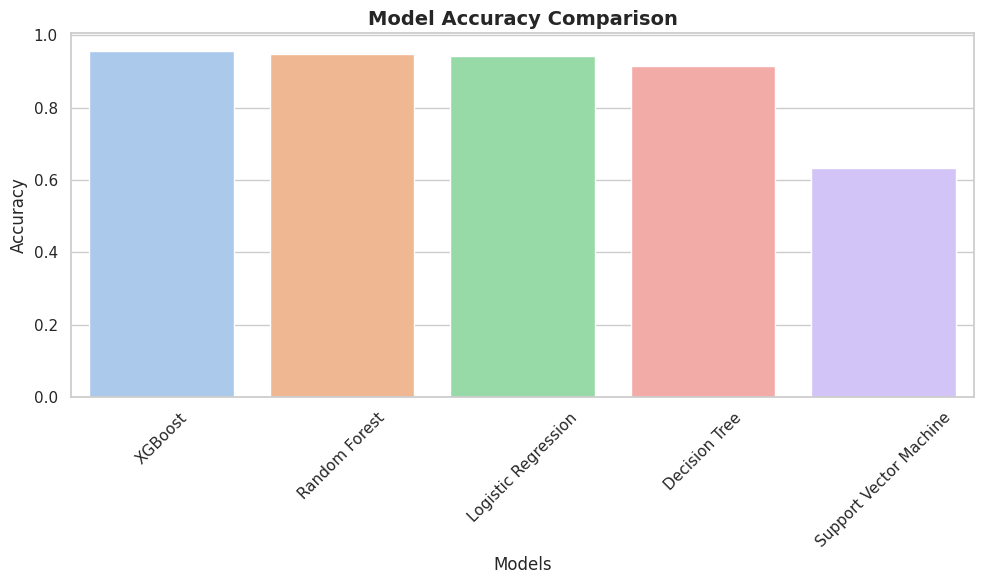

In [ ]:
plt.figure(figsize=(10, 6))
palette = sns.color_palette("pastel")
sns.barplot(data=results_df, x='Model', y='Accuracy', palette=palette)

plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('Models', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

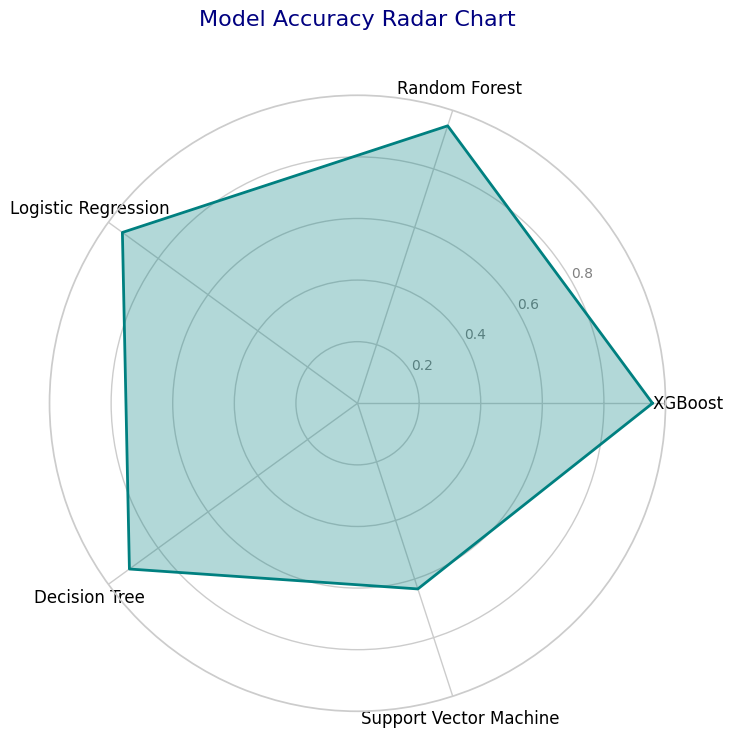

In [ ]:
categories = list(results_df['Model'])
values = list(results_df['Accuracy'])
values += values[:1]

N = len(categories)

angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

plt.xticks(angles[:-1], categories, color='black', size=12)

ax.set_rlabel_position(30)
plt.yticks([0.2, 0.4, 0.6, 0.8], ["0.2", "0.4", "0.6", "0.8"], color="grey", size=10)
plt.ylim(0, 1)

ax.plot(angles, values, linewidth=2, linestyle='solid', color='teal')
ax.fill(angles, values, 'teal', alpha=0.3)

plt.title('Model Accuracy Radar Chart', size=16, color='navy', y=1.1)
plt.show()

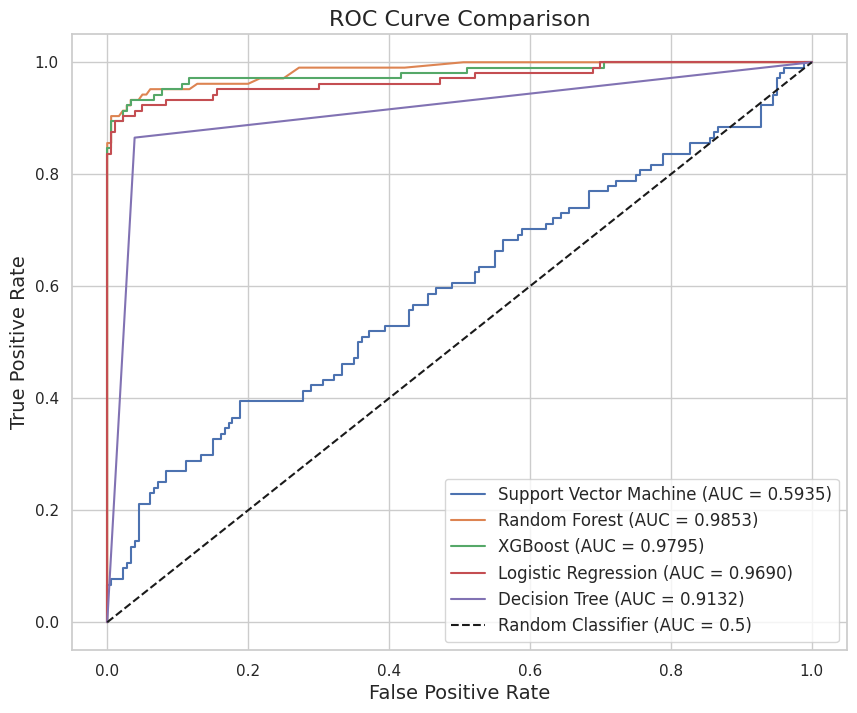

In [ ]:
plt.figure(figsize=(10, 8))

for name, model in models.items():
    model.fit(X_train, Y_train)
    y_prob = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(Y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)')

plt.title('ROC Curve Comparison', fontsize=16)
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True)
plt.show()

# **Conclusion**

Credit history is the most important feature
Higher income improves loan approval chances
The model performs well with acceptable accuracy
XGboost is effective for binary classification